##### Quantum Data Science 2024/2025
# Lecture 5 - Quantum Feature maps, Kernels and Support Vector Machines

<!-- no toc -->
### Contents 

1. [Recap: Support Vector Machines with kernels](#svm_kernels)
2. [Data encoding as a Quantum Feature map](#qfeaturemap)
3. [Quantum Kernel estimation](#qke)
4. [Quantum Kernel estimation in pennylane](#qke)
5. [SVM's with Quantum Kernels for ad_hoc_dataset](#qke_ad_hoc)
   1. [example with amplitude encoding](#qke_ad_hoc_amplitude_encoding)
   3. [example with the IQP encoding](#qke_iqp_encoding)
6. [Caveats](#caveats)
7. [References](#references)

## 1. Recap: Support Vector Machines with kernels <a id='margins_intuition'></a>
    
*Support vector machines (SVMs)* are a powerful class of supervised learning algorithms (even today believed by some to be the best off the shelf supervised learning algorithm) for classification and regression problems. In this lecture, we will focus on the binary classification problem. The main idea behind SVMs is to find the hyperplane that best separates the data into different classes. 

Why hyperplanes ? From the *Occam’s razor principle*, hypothesis sets with smaller complexity provide better learning guarantees. A natural hypothesis set with relatively small complexity is that of *linear classifiers*, or hyperplanes.

$$ \mathcal{H} = \{x \mapsto sign(w^T x + b) : x \in \mathbb{R}^M, w \in \mathbb{R}^M, b \in \mathbb{R} \}$$ 


which is other way of saying what we had in our percetron algorithm with the heaviside step function.

General equation of the hyperplane $w^T x + b=0$. Consider labels $y \in \{-1,1\}$.

The sign operator returns the sign of the operation inside the brackets. Thus, the hypothesis labels positively all points falling on one side of the hyperplane and negatively all others (Figure below left)

<p align="center">
 <img width="1000" height="450" src="images/margins.png">
</p>

Which hyperplane should we choose from the infinite number of possible hyperplanes? We don't know yet, but one thing we can agree is that the points the further away from the hyperplane, the more confident we are about their classification right ? In the figure in the middle we notice that we need a very small change in the green hyperplane to misclassify a datapoint. Therefore, a good hyperplane would be one that has a large margin between points of different classes. This is the intuition behind SVMs and the reason why they are called *maximum margin classifiers* (illustrated in the figure on the right).

#### --- Dual formulation <a id='dual_formulation'></a>

However, notice that we are trying to optimize a function in which the weights $w$ are $N$ dimensional with $N$ being the number of features. This is a problem because the optimization problem becomes computationally expensive as the number of features increases. 

The dual formulation removes the dependence on the weights $w$ be noticing that the optimal weights can be expressed as a linear combination of the training data points if we set the derivatives to zero (convex problem -> KKT conditions), simplifying the problem to: 

$$
\begin{equation*}
L(\alpha) = \sum_{i=0}^{M-1} \alpha_i - \frac{1}{2} \sum_{i=0}^{M-1} \sum_{j=0}^{M-1} \alpha_i \alpha_j y_i y_j x_i \cdot x_j
\end{equation*}
$$

subject to the constraints $\alpha_i \geq 0$ and $\sum_{i=0}^{M-1} \alpha_i y_i = 0$. 

Thus, we optimize for as many parameters as the number of training data points, which is computationally more efficient, and after the optimization only support vectors will have non-zero $\alpha_i$ values.

The model can be expressed as:

$$
\begin{equation*}
f(x) =\sum_{i=0}^{M-1} \alpha_i y_i x_i \cdot x + b
\end{equation*}
$$

#### --- Kernel trick <a id='dual_formulation'></a>

Recall that the SVM is a linear model , thus it cannot classify non-linear data. However, we can use the kernel trick to map the data into a higher dimensional space where it may be easier to separate. 

It replaces the dot product $x_i \cdot x_j$ with a dot product in a feature space of higher dimensionality, where the data is linearly separable by a hyperplane.

<p align="center">
    <img width="1000" height="500" src="images/kernel_trick.png">
</p>



We replace the inner product with an inner product in a higher dimensional space:

$$
\begin{equation*}
L(\alpha) = \sum_{i=0}^{M-1} \alpha_i - \frac{1}{2} \sum_{i=0}^{M-1} \sum_{j=0}^{M-1} \alpha_i \alpha_j y_i y_j k(x_i,x_j)
\end{equation*}
$$

where $k$ is the kernel function that acts as a similarity measure between two points $x_i$ and $x_j$ in feature space: 

$$ K: \Omega \times \Omega \mapsto \mathbb{R} $$
$$ K: (x,y) \longmapsto k(x,y)=\langle\phi(x) , \phi(y)\rangle $$

The Kernel trick allow us to compare points in high dimensional feature spaces by using the original input vectors! 

**Mercer's condition**: $k(x,y) \geq 0$  and the kernel matrix $\mathcal{K}$:

$$ \mathcal{K} = \left[ k(x,y) \right]_{xy}$$ 

Thus, the kernel function is positive definite and symmetric $k(x,x') \geq 0$ and the optimization problem is convex.

Therefore, the Kernel matrix that compare each pair of points is also positive definite with diagonal ones $K_{ii} = 1$



  **stricly convex**. This is awesome because it tell us that we have a unique solution - Any local minimum is the global minimum. This is not true is general neural networks algorithms. Here there are well established theoretical guarantees. For instance the the number of datapoints necessary to generalize and guarantee a minimum prediction error - Sample complexity. See [1]
  
<p align="center">
 <img width="800" height="400" src="images/convex.jpeg">
</p>



----------------
#### Examples of kernels:

<p align="center">
<img width="/00" height="300" src="images/kernels.png">
</p>

----------------



---

$\gamma$ in the Gaussian (or Radial Basis Function RBF) kernel is a hyperparameter that controls the bandwidth of the kernel. 

Usually $\gamma=\frac{1}{2\sigma^2}$ where $\sigma$ is the standard deviation of the Gaussian. Variance $\sigma^2 = 1$ is a common choice. But it depends on the problem and fine tuning may be needed.



---

## 2 - Quantum Feature maps and kernels <a id="qfeaturemap"></a>

### If the kernel can be any positive definite function, then the kernel can also come from a quantum circuit ! All we need is a quantum feature map and a way of comparing data datapoins in quantum feature space!

why ? 


- Because quantum computers already work in high dimensional feature spaces - we can benefit from quantum computers that easily manipulate data that live in $2^n$ in  Hilbert space. We just need to map classical data to a quantum computer and then compare the data in quantum feature space. Right? 
  
    How? 

    

### Quantum Feature map:

$$ \phi: x \mapsto |\phi(x) \rangle $$

### Quantum kernel: 

For two points $x$ and $y$ , we can use the overlap: 

$$k(x,y) = |\langle \phi(x) | \phi(y) \rangle|^2 $$

as the kernel function where $|\$ and $\phi$ is the quantum feature map (mapping of classical data into quantum system).


This is indeed a kernel. Notice that this is also positive semidefinite ( $k(x,y) \geq 0 $)

## 3 - Quantum Kernel estimation <a id="qke"></a>


Recall that the overlap can be obtained with standard SWAP TEST / INVERSION TEST circuits (lecture 1 and 2).

<p align="center">
 <img width="850" height="350" src="images/swap_test_inversion_test.png">
</p>


#### Therefore , data encoding + swap tests is all we need to quantum kernels

#### Types of functions being generated from the data encoding 


<p align="center">
 <img width="/00" height="300" src="images/kernel_types.png">
</p>

*"Because quantum computers already work in high dimensional feature spaces - we can benefit from quantum computers that easily manipulate data that live in $2^n$ in  Hilbert space. We just need to map classical data to a quantum computer and then compare the data in quantum feature space. Right?"*
  

Well, not entirely true ... 

Notice that classical computers can efficiently compute said kernels. Therefore, the goal here is to exploit quantum processes that are not efficiently recovered by a classical computer and create powerful feature maps! 

One such example is the IQP encoding: 

<p align="center">
 <img width="800" height="250" src="images/IQP.png">
</p>

which is conjectured to be hard to simulate classically, as we increase the number of layers, especially for layers > 2. 



## 4 - Quantum Kernel estimation in pennylane <a id="qke_qiskit"></a>


In [15]:
# angle encoding kernel 
import pennylane as qml
from pennylane import numpy as np

def angle_encoding(x, sigma="Y"):
    
    max_abs_feature = np.max(np.abs(x))
    x_normalized = x/max_abs_feature

    qml.AngleEmbedding(x_normalized, wires=range(len(x)), rotation=sigma)


def kernel(x1, x2, n_qubits , sigma="y"):
    angle_encoding(x1, sigma)
    qml.adjoint(angle_encoding)(x2, sigma)

    return qml.expval(qml.Projector(np.zeros(n_qubits), wires=range(n_qubits)))

Let $X = \{[1.0,1.0,1.0,1.0,1.0], [10.0,5.0,10.0,5.0,10.0], [1.0,1.0,1.0,1.0,1.0], [10.0,5.0,10.0,5.0,10.0]\}$ be an hypothetical dataset

In [16]:
X = np.array([[1.0,1.0,1.0,1.0,1.0], [10.0,5.0,10.0,5.0,10.0], [1.0,1.0,1.0,1.0,1.0], [10.0,5.0,10.0,5.0,10.0]])

n_qubits = 5

dev = qml.device("default.qubit", wires=n_qubits)

qkernel = qml.QNode(kernel, dev)

K = np.zeros((len(X), len(X)))

for i in range(len(X)):
    for j in range(len(X)):
        if i == j:
            K[i, j] = 1
        else:
            K[i, j] = qkernel(X[i], X[j], n_qubits, sigma="Y")


print(K)



[[1.         0.88132907 1.         0.88132907]
 [0.88132907 1.         0.88132907 1.        ]
 [1.         0.88132907 1.         0.88132907]
 [0.88132907 1.         0.88132907 1.        ]]


#### Evaluate the kernel on the dataset:


In [19]:
#or using directly sklearn SVC

from sklearn.svm import SVC


svc = SVC(kernel='precomputed')

Y = [0,1,0,1]

svc.fit(K, Y)

svc_score = svc.score(K, Y)

print(svc_score)



1.0


## 5. SVM's with Quantum Kernels for ad_hoc_dataset <a id="qke_ad_hoc"></a>

Consider the ad_hoc_dataset from the previous lecture with 10 features and two classes. 

Use the quantum kernel estimator in quantum qSVM algorithm to classify the data and compare with classical kernels



In [31]:
#import ad_hoc_data from sklearn
from sklearn.datasets import make_classification


# generate the training and testing datasets
n_features = 4
n_samples = 100
n_classes = 2

#train data and test data
training_features, training_labels = make_classification(n_samples=n_samples, n_features=n_features, n_informative=n_features, n_redundant=0, n_clusters_per_class=1, n_classes=n_classes)
test_features, test_labels = make_classification(n_samples=n_samples, n_features=n_features, n_informative=n_features, n_redundant=0, n_clusters_per_class=1, n_classes=n_classes)



#normalize the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
training_features = scaler.fit_transform(training_features)
test_features = scaler.transform(test_features)



#### 5.1 - Example for amplitude encoding - estimating the kernel matrix by hand <a id="qke_ad_hoc_amplitude_encoding"></a>

In [32]:

def kernel(x1, x2, n_qubits):
    qml.AmplitudeEmbedding(x1, normalize=True, wires=range(n_qubits))
    qml.adjoint(qml.AmplitudeEmbedding)(x2, normalize=True, wires=range(n_qubits))

    return qml.expval(qml.Projector(np.zeros(n_qubits), wires=range(n_qubits)))

n_qubits = int(np.log2(n_features))

dev = qml.device("default.qubit", wires=n_qubits)

qkernel = qml.QNode(kernel, dev)

In [33]:
print("x0 - {} , x1 - {}".format(training_features[0],training_features[1]))

qkernel(training_features[0],training_features[1], n_qubits)

x0 - [0.42374476 0.83760483 0.35611561 0.5911837 ] , x1 - [0.11858303 0.         0.77886368 0.49660243]


tensor(0.32776433, requires_grad=True)

##### kernel matrix

In [34]:
def kernel_matrix(X,Y, set_diagonal_one=True):

        n = len(X)
        m = len(Y)
        
        K = np.zeros((n,m))
        
        #use symmetry of the kernel to estimate just half the matrix
        for i in range(n):
            K[i,i]=1.0
            for j in range(i+1,m):

                K[i,j] = qkernel(X[i],Y[j], n_qubits)
                K[j,i] = K[i,j]
        
        return K

In [35]:
kernel_matrix_amplitude_encoding = kernel_matrix(training_features[:10],training_features[:10])

##### use the precomputed kernel in SVC 



In [36]:
# use the precomputed kernel in SVC 

from sklearn.svm import SVC

svc = SVC(kernel='precomputed')

svc.fit(kernel_matrix_amplitude_encoding, training_labels[:10])

svc_score = svc.score(kernel_matrix_amplitude_encoding, training_labels[:10])

print(svc_score)

0.9


### 5.3 - Example using the IQP encoding <a id="qke_iqp_encoding"></a>

(<Figure size 3300x500 with 1 Axes>, <Axes: >)

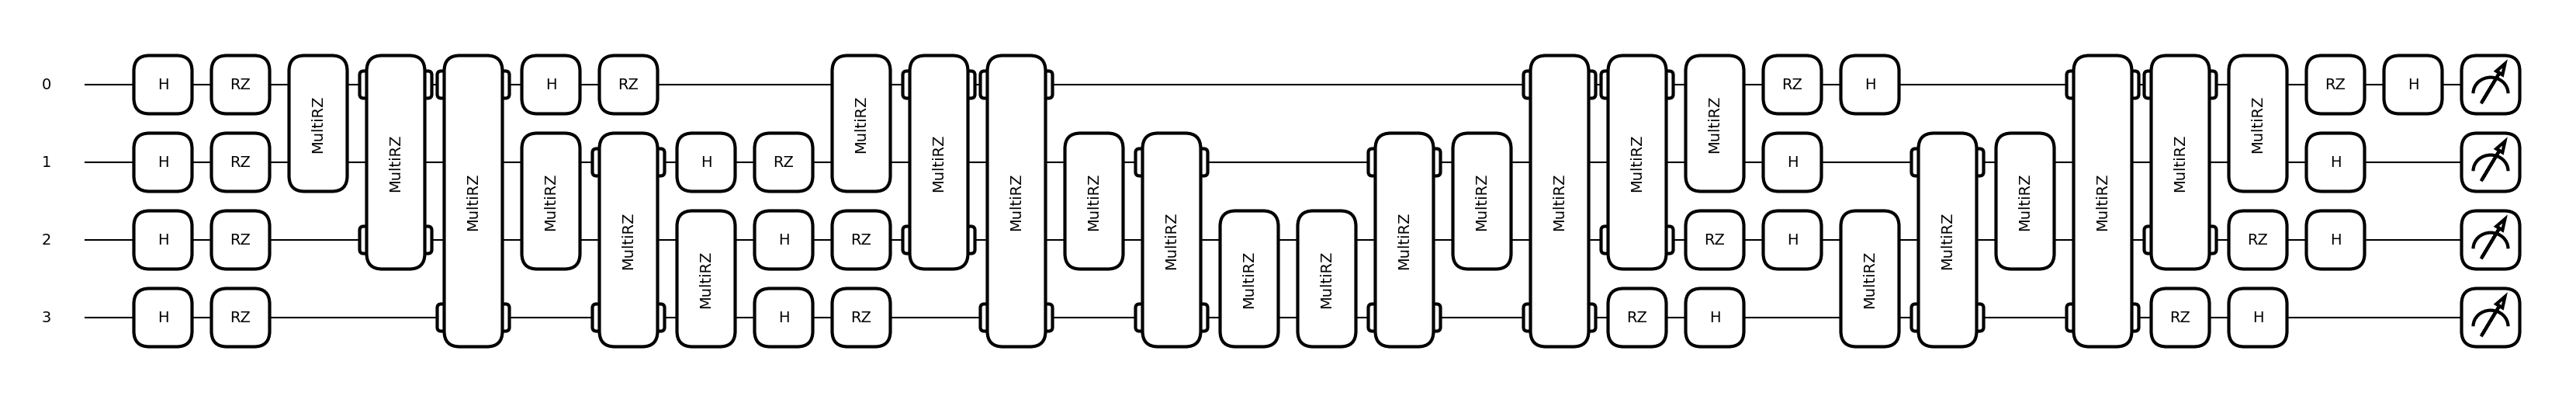

In [39]:

def kernel(x1, x2, n_qubits):
    qml.IQPEmbedding(x1, wires=range(n_qubits), n_repeats=2)
    qml.adjoint(qml.IQPEmbedding)(x2, wires=range(n_qubits), n_repeats=2)

    return qml.expval(qml.Projector(np.zeros(n_qubits), wires=range(n_qubits)))

n_qubits = n_features

dev = qml.device("default.qubit", wires=n_qubits)

qkernel = qml.QNode(kernel, dev)

qcompiled = qml.compile(qkernel)

qml.draw_mpl(qcompiled)(training_features[0],training_features[1], n_qubits)

In [43]:
kernel_matrix = kernel_matrix(training_features[:10],training_features[:10])

print(kernel_matrix_amplitude_encoding)


[[1.         0.66615311 0.88376586 0.65197452 0.80543262 0.78821071
  0.72249994 0.78907548 0.74061799 0.79444291]
 [0.66615311 1.         0.56966676 0.65461309 0.70931649 0.63241559
  0.67267027 0.83291485 0.83499496 0.66996106]
 [0.88376586 0.56966676 1.         0.68079788 0.69044989 0.88397583
  0.72529297 0.69936237 0.68839517 0.71430392]
 [0.65197452 0.65461309 0.68079788 1.         0.82977221 0.82896717
  0.95708522 0.85021279 0.8462411  0.74791938]
 [0.80543262 0.70931649 0.69044989 0.82977221 1.         0.76140015
  0.92299813 0.94838672 0.90945958 0.90548557]
 [0.78821071 0.63241559 0.88397583 0.82896717 0.76140015 1.
  0.83464413 0.81093872 0.81697813 0.78099004]
 [0.72249994 0.67267027 0.72529297 0.95708522 0.92299813 0.83464413
  1.         0.90287437 0.89029507 0.84562627]
 [0.78907548 0.83291485 0.69936237 0.85021279 0.94838672 0.81093872
  0.90287437 1.         0.99016772 0.91709458]
 [0.74061799 0.83499496 0.68839517 0.8462411  0.90945958 0.81697813
  0.89029507 0.99016

In [45]:
# or pennylane's direct implementation

def kernel(x1, x2):
    l = len(x1)
    qml.IQPEmbedding(x1, wires=range(l), n_repeats=2)
    qml.adjoint(qml.IQPEmbedding)(x2, wires=range(l), n_repeats=2)

    return qml.expval(qml.Projector(np.zeros(l), wires=range(l)))

n_qubits = n_features

dev = qml.device("default.qubit", wires=n_qubits)

qkernel = qml.QNode(kernel, dev)

kernel_matrix_amplitude_encoding = qml.kernels.kernel_matrix(training_features[:10],training_features[:10], qkernel)

print(kernel_matrix_amplitude_encoding)

[[1.         0.66615311 0.88376586 0.65197452 0.80543262 0.78821071
  0.72249994 0.78907548 0.74061799 0.79444291]
 [0.66615311 1.         0.56966676 0.65461309 0.70931649 0.63241559
  0.67267027 0.83291485 0.83499496 0.66996106]
 [0.88376586 0.56966676 1.         0.68079788 0.69044989 0.88397583
  0.72529297 0.69936237 0.68839517 0.71430392]
 [0.65197452 0.65461309 0.68079788 1.         0.82977221 0.82896717
  0.95708522 0.85021279 0.8462411  0.74791938]
 [0.80543262 0.70931649 0.69044989 0.82977221 1.         0.76140015
  0.92299813 0.94838672 0.90945958 0.90548557]
 [0.78821071 0.63241559 0.88397583 0.82896717 0.76140015 1.
  0.83464413 0.81093872 0.81697813 0.78099004]
 [0.72249994 0.67267027 0.72529297 0.95708522 0.92299813 0.83464413
  1.         0.90287437 0.89029507 0.84562627]
 [0.78907548 0.83291485 0.69936237 0.85021279 0.94838672 0.81093872
  0.90287437 1.         0.99016772 0.91709458]
 [0.74061799 0.83499496 0.68839517 0.8462411  0.90945958 0.81697813
  0.89029507 0.99016

In [46]:
# use the precomputed kernel in SVC 

from sklearn.svm import SVC

svc = SVC(kernel='precomputed')

svc.fit(kernel_matrix_amplitude_encoding, training_labels[:10])

svc_score = svc.score(kernel_matrix_amplitude_encoding, training_labels[:10])

print(svc_score)

1.0


## 6 - Caveats <a id="caveats"></a>

- Quantum kernels are not guaranteed to outperform classical kernels - classical simulation hardness does not imply usefulness of the encoding in solving a task.
- Expressivity of the kernel is important same as in VQC - Trainable kernels (kernel alignment) can be used to improve performance (see [2])
- Tradeoff between expressivity and kernel estimation - Vanishing similarity problem similar to barren plateaus in (VQC see [3])


## 7 - References <a id="references"></a>

* [1] - Mohri, Mehryar et al. “Foundations of Machine Learning.” Adaptive computation and machine learning (2012).
* [2] - Incudini,M et.al Automatic and effective discovery of quantum kernels https://arxiv.org/abs/2209.11144
* [3] - Thanasilp, S et.al Exponential concentration in quantum kernel methods https://arxiv.org/abs/2208.11060